# Customer Repeat Purchase & Retention Analysis
### An Olist Brazilian E-Commerce Case Study

**Prepared by:** Data Analytics Team
**Tools:** SQL (SQLite), Python, Pandas, Matplotlib, Seaborn, SciPy, Scikit-learn
**Dataset:** [Olist Brazilian E-Commerce Public Dataset](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce) (Kaggle)

## Executive Summary

Olist is a Brazilian e-commerce marketplace. Like most online retailers, it wants more customers to come back and buy again. This analysis looks at three years of order history to answer a simple question: **who comes back, and what separates them from customers who buy only once?**

**Headline numbers**

- Out of **96,096** customers, only **3.12%** placed a second order during the period covered by the data. The remaining **96.88%** were one-time buyers.
- Customers who did come back usually did so quickly. Half of all second purchases happened within **28 days** of the first one.
- Repeat customers spent more overall (**R$302** on average) than one-time customers (**R$161**), even though their individual orders were slightly smaller on average. The extra value comes from buying more than once, not from spending more per order.
- Review scores, delivery speed, customer location, and product category all showed some statistical relationship with repeat buying, but every one of these relationships was weak. A predictive model built from all of them together could only correctly flag repeat customers about half the time.

**Bottom line:** Repeat purchasing at Olist is rare, and none of the factors in this dataset (satisfaction, delivery, geography, category) explain it strongly on their own or in combination. The clearest lever available is timing. Since most repeat purchases happen within about a month, that first month after a purchase is the highest-value window for a follow-up offer or engagement effort.

The rest of this notebook walks through how each of these findings was reached, using SQL for the data work and Python for statistics and visualization.

## How This Notebook Is Organized

This project is written so it can be read two ways at once.

**If you are here for the business story**, read the plain-language text between the code cells. Each section opens with a business question, closes with a plain-English takeaway, and includes a chart wherever a picture explains the finding faster than a paragraph.

**If you are here to review the analytical work**, every result is produced by a SQL query against an in-memory relational database, shown in full in the code cells. Python is used only for statistical testing, visualization, and one predictive model at the end. The SQL covers joins across seven tables, common table expressions, window functions, conditional aggregation, and indexing for performance.

A short note on scope: customer status here (one-time vs. repeat) is always based on **orders observed inside the dataset's own time window**. Because the dataset stops in 2018, a one-time customer here is not necessarily a lost customer forever. They may simply not have purchased again yet within the observed period. This distinction matters and is used consistently throughout.

## Dataset Overview

| Item | Description |
|---|---|
| Dataset | Olist Brazilian E-Commerce Public Dataset |
| Business domain | E-commerce marketplace |
| Observation period | 2016 to 2018 |
| Customers analyzed | 96,096 unique customers |
| Orders analyzed | 99,441 orders |
| Source tables used | 7 of 9 relational tables (full schema shown in the companion PDF) |
| Database engine | SQLite, run in-memory through Python's `sqlite3` module |
| Analysis languages | SQL for data retrieval, Python for statistics and visualization |
| Statistical methods | Welch's t-test, Mann-Whitney U test, Chi-square test of independence, Cramer's V |
| Predictive method | Logistic regression |
| Customer identifier | `customer_unique_id` |
| Order identifier | `order_id` |

The queries in this notebook run against SQLite for full reproducibility without an external database server. The SQL is standard enough to run on PostgreSQL, MySQL, or BigQuery with only minor syntax adjustments, mainly around date functions.

## Business Problem

Olist wants to understand why some customers return to buy again while most do not. This analysis investigates:

- How many customers are one-time buyers versus repeat buyers
- How often repeat customers purchase, and how quickly they come back
- Whether order value and total spending differ between the two groups
- Whether customer experience (reviews, delivery speed) relates to repeat buying
- Whether geography or product category relate to repeat buying
- Which of these factors, taken together, best explain repeat purchasing

The goal is to find **patterns associated with repeat purchasing**, not to claim that any single factor causes it. Correlation is not causation, and this distinction is treated carefully throughout, especially in the statistical testing sections.

## Customer Status Definitions

The dataset does not include a confirmed churn flag or a "customer left" indicator, so customer status is defined directly from observed order history:

- **One-time customer**: exactly one observed order
- **Repeat customer**: more than one observed order
- **Observed inactivity**: no additional purchase occurred within the dataset's observation window

A one-time customer is not treated as a confirmed lost customer. They may return after the dataset's cutoff date. This is why the analysis speaks in terms of "observed" repeat purchasing rather than final churn.

## Questions This Analysis Answers

1. What does the dataset contain, and is it clean enough to analyze?
2. How many customers are one-time versus repeat buyers?
3. Among repeat customers, how often do they purchase?
4. How long does it typically take a customer to make a second purchase?
5. Do customer experience factors (reviews, delivery) relate to repeat buying?
6. Does geography or product category relate to repeat buying?
7. Which characteristics, combined, best explain who becomes a repeat customer?

---
# Part 1: Preparing and Auditing the Data

## Setup

The cell below loads the libraries used throughout the notebook and sets a consistent visual style so every chart in this report looks like it belongs to the same document.

In [1]:
import os
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelweight"] = "bold"

# Consistent color palette used across every chart in this notebook
COLOR_PRIMARY = "#1B4F72"    # dark blue, used for the "repeat" or highlighted group
COLOR_NEUTRAL = "#AEB6BF"    # grey, used for the baseline or "one-time" group
COLOR_ACCENT = "#E67E22"     # orange, used sparingly for emphasis
CMAP_SEQUENTIAL = plt.cm.Blues


def style_axes(ax, title, xlabel="", ylabel=""):
    """Apply a consistent title/label style to a chart axis."""
    ax.set_title(title, pad=14)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=10)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=10)


def label_hbars(ax, bars, fmt="{:.2f}%"):
    """Write a value label at the end of each horizontal bar."""
    x_range = ax.get_xlim()[1] - ax.get_xlim()[0]
    for bar in bars:
        width = bar.get_width()
        ax.text(
            width + x_range * 0.01,
            bar.get_y() + bar.get_height() / 2,
            fmt.format(width),
            va="center", ha="left", fontweight="bold", fontsize=9,
        )


def label_vbars(ax, bars, fmt="{:.2f}%"):
    """Write a value label above each vertical bar."""
    y_range = ax.get_ylim()[1] - ax.get_ylim()[0]
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + y_range * 0.01,
            fmt.format(height),
            va="bottom", ha="center", fontweight="bold", fontsize=9,
        )

os.makedirs("charts", exist_ok=True)

print("Libraries loaded and chart style configured.")

Libraries loaded and chart style configured.


## Load the Data

The source files are the Olist Brazilian E-Commerce CSVs. This analysis uses 7 of the 9 tables in the public dataset. The `sellers` and `geolocation` tables are part of the full schema (shown in the companion PDF) but are not required to answer the retention questions this notebook focuses on, so they were left out to keep the analysis focused.

Each CSV is loaded into a Pandas DataFrame and then registered as a table in an in-memory SQLite database, so the rest of the notebook can query the data with plain SQL.

In [2]:
DATA_DIR = "data"

customers = pd.read_csv(f"{DATA_DIR}/olist_customers_dataset.csv")
orders = pd.read_csv(f"{DATA_DIR}/olist_orders_dataset.csv")
order_items = pd.read_csv(f"{DATA_DIR}/olist_order_items_dataset.csv")
order_payments = pd.read_csv(f"{DATA_DIR}/olist_order_payments_dataset.csv")
order_reviews = pd.read_csv(f"{DATA_DIR}/olist_order_reviews_dataset.csv")
products = pd.read_csv(f"{DATA_DIR}/olist_products_dataset.csv")
category_translation = pd.read_csv(f"{DATA_DIR}/product_category_name_translation.csv")

conn = sqlite3.connect(":memory:")

customers.to_sql("customers", conn, index=False, if_exists="replace")
orders.to_sql("orders", conn, index=False, if_exists="replace")
order_items.to_sql("order_items", conn, index=False, if_exists="replace")
order_payments.to_sql("order_payments", conn, index=False, if_exists="replace")
order_reviews.to_sql("order_reviews", conn, index=False, if_exists="replace")
products.to_sql("products", conn, index=False, if_exists="replace")
category_translation.to_sql("category_translation", conn, index=False, if_exists="replace")

# Indexes mirror what would be used in a production database to keep the
# joins and window functions in the sections below fast.
conn.execute("CREATE INDEX idx_customers_customer_id ON customers(customer_id)")
conn.execute("CREATE INDEX idx_customers_unique_id ON customers(customer_unique_id)")
conn.execute("CREATE INDEX idx_orders_customer_id ON orders(customer_id)")
conn.execute("CREATE INDEX idx_orders_purchase ON orders(customer_id, order_purchase_timestamp, order_id)")
conn.execute("CREATE INDEX idx_order_items_order_id ON order_items(order_id)")
conn.execute("CREATE INDEX idx_order_payments_order_id ON order_payments(order_id)")
conn.execute("CREATE INDEX idx_order_reviews_order_id ON order_reviews(order_id)")
conn.execute("CREATE INDEX idx_products_product_id ON products(product_id)")
conn.commit()

pd.read_sql("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", conn)

,name
0,category_translation
1,customers
2,order_items
3,order_payments
4,order_reviews
5,orders
6,products


## Data Types and Cleaning

Order and review timestamps load from CSV as plain text. They are converted to proper datetime values so date arithmetic (time to second purchase, delivery delay, and so on) works correctly later in the notebook.

In [3]:
order_date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]
for column in order_date_columns:
    orders[column] = pd.to_datetime(orders[column])

order_items["shipping_limit_date"] = pd.to_datetime(order_items["shipping_limit_date"])

for column in ["review_creation_date", "review_answer_timestamp"]:
    order_reviews[column] = pd.to_datetime(order_reviews[column])

# Refresh the SQL tables now that the date columns are typed correctly
orders.to_sql("orders", conn, index=False, if_exists="replace")
order_items.to_sql("order_items", conn, index=False, if_exists="replace")
order_reviews.to_sql("order_reviews", conn, index=False, if_exists="replace")
conn.execute("CREATE INDEX idx_orders_customer_id ON orders(customer_id)")
conn.execute("CREATE INDEX idx_orders_purchase ON orders(customer_id, order_purchase_timestamp, order_id)")
conn.execute("CREATE INDEX idx_order_items_order_id ON order_items(order_id)")
conn.execute("CREATE INDEX idx_order_reviews_order_id ON order_reviews(order_id)")
conn.commit()

print("Date columns converted.")

Date columns converted.


## Data Quality Audit

Before analyzing anything, every table is checked for its size, missing values, and duplicate rows. This is standard practice and it also tells us which missing values are actually a data quality problem versus a normal, expected gap.

In [4]:
def audit_table(df, name):
    return {
        "table": name,
        "rows": len(df),
        "columns": df.shape[1],
        "missing_values": int(df.isnull().sum().sum()),
        "duplicate_rows": int(df.duplicated().sum()),
    }

audit_summary = pd.DataFrame([
    audit_table(customers, "customers"),
    audit_table(orders, "orders"),
    audit_table(order_items, "order_items"),
    audit_table(order_payments, "order_payments"),
    audit_table(order_reviews, "order_reviews"),
    audit_table(products, "products"),
    audit_table(category_translation, "category_translation"),
])
audit_summary

,table,rows,columns,missing_values,duplicate_rows
0,customers,99441,5,0,0
1,orders,99441,8,4908,0
2,order_items,112650,7,0,0
3,order_payments,103886,5,0,0
4,order_reviews,99224,7,145903,0
5,products,32951,9,2448,0
6,category_translation,71,2,0,0


In [5]:
# Targeted checks for known problem areas: negative amounts, and
# deliveries that are recorded as happening before the order was placed.
negative_prices = int((order_items["price"] < 0).sum())
negative_freight = int((order_items["freight_value"] < 0).sum())
delivered_before_purchase = int(
    (orders["order_delivered_customer_date"] < orders["order_purchase_timestamp"]).sum()
)
products_missing_category = int(products["product_category_name"].isnull().sum())

quality_checks = pd.DataFrame([
    {"check": "Negative item prices", "result": negative_prices},
    {"check": "Negative freight charges", "result": negative_freight},
    {"check": "Orders delivered before they were purchased", "result": delivered_before_purchase},
    {"check": "Products missing a category name", "result": products_missing_category},
])
quality_checks

,check,result
0,Negative item prices,0
1,Negative freight charges,0
2,Orders delivered before they were purchased,0
3,Products missing a category name,610


### Audit Findings

The audit did not surface any row-level errors that needed to be fixed in Python. No negative prices, no negative freight charges, and no orders delivered before they were placed.

The missing values that do exist were kept rather than dropped, because in every case they represent a legitimate gap rather than a bad record:

- In `orders`, some delivery timestamps are missing because that step of the order simply had not happened yet (or was cancelled). These records still matter for order status and delivery analysis.
- In `order_reviews`, review titles and written comments are frequently missing because customers are not required to write one. The review score itself is still present and usable.
- In `products`, a small number of products (610 out of roughly 33,000) are missing a category name. These rows were kept, since a missing category does not prevent the product from being linked to its order. It only becomes relevant in the product-category section later in this notebook, where those rows are simply excluded from that specific calculation.

Nothing was removed automatically. Each gap was handled according to what it means for the specific analysis it touches.

---
# Part 2: Business KPIs at a Glance

Before testing specific hypotheses, it helps to establish the headline numbers that frame the rest of the analysis. Each metric below is produced by its own SQL query.

In [6]:
kpi_customer_counts = pd.read_sql("""
    SELECT
        c.customer_unique_id,
        COUNT(o.order_id) AS order_count
    FROM customers c
    JOIN orders o
        ON c.customer_id = o.customer_id
    GROUP BY c.customer_unique_id
""", conn)

total_customers = len(kpi_customer_counts)
one_time_customers = int((kpi_customer_counts["order_count"] == 1).sum())
repeat_customers = int((kpi_customer_counts["order_count"] > 1).sum())
total_orders = int(orders["order_id"].nunique())
avg_orders_per_customer = total_orders / total_customers

kpi_second_purchase = pd.read_sql("""
    WITH ordered_purchases AS (
        SELECT
            c.customer_unique_id,
            o.order_purchase_timestamp,
            ROW_NUMBER() OVER (
                PARTITION BY c.customer_unique_id
                ORDER BY o.order_purchase_timestamp ASC, o.order_id
            ) AS purchase_seq
        FROM customers c
        JOIN orders o
            ON c.customer_id = o.customer_id
        WHERE o.order_status = 'delivered'
    ),
    first_and_second AS (
        SELECT
            customer_unique_id,
            MIN(CASE WHEN purchase_seq = 1 THEN order_purchase_timestamp END) AS first_purchase,
            MIN(CASE WHEN purchase_seq = 2 THEN order_purchase_timestamp END) AS second_purchase
        FROM ordered_purchases
        WHERE purchase_seq IN (1, 2)
        GROUP BY customer_unique_id
    )
    SELECT
        customer_unique_id,
        JULIANDAY(DATE(second_purchase)) - JULIANDAY(DATE(first_purchase)) AS days_to_second_purchase
    FROM first_and_second
    WHERE second_purchase IS NOT NULL
""", conn)
median_days_to_second_purchase = kpi_second_purchase["days_to_second_purchase"].median()

kpi_order_value = pd.read_sql("""
    SELECT
        o.order_id,
        SUM(oi.price + oi.freight_value) AS order_value
    FROM orders o
    JOIN order_items oi
        ON o.order_id = oi.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY o.order_id
""", conn)
avg_order_value = kpi_order_value["order_value"].mean()

kpi_customer_spend = pd.read_sql("""
    SELECT
        c.customer_unique_id,
        SUM(oi.price + oi.freight_value) AS total_spend
    FROM customers c
    JOIN orders o
        ON c.customer_id = o.customer_id
    JOIN order_items oi
        ON o.order_id = oi.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
""", conn)
avg_customer_spend = kpi_customer_spend["total_spend"].mean()

avg_review_score = order_reviews["review_score"].mean()

kpi_table = pd.DataFrame([
    {"Metric": "Total customers", "Value": f"{total_customers:,}"},
    {"Metric": "One-time customers", "Value": f"{one_time_customers:,} ({one_time_customers/total_customers:.2%})"},
    {"Metric": "Repeat customers", "Value": f"{repeat_customers:,} ({repeat_customers/total_customers:.2%})"},
    {"Metric": "Total orders", "Value": f"{total_orders:,}"},
    {"Metric": "Average orders per customer", "Value": f"{avg_orders_per_customer:.2f}"},
    {"Metric": "Median time to a second purchase", "Value": f"{median_days_to_second_purchase:.0f} days"},
    {"Metric": "Average delivered order value", "Value": f"R$ {avg_order_value:,.2f}"},
    {"Metric": "Average delivered customer spend", "Value": f"R$ {avg_customer_spend:,.2f}"},
    {"Metric": "Average review score", "Value": f"{avg_review_score:.2f} / 5"},
])
kpi_table

,Metric,Value
0,Total customers,"96,096"
1,One-time customers,"93,099 (96.88%)"
2,Repeat customers,"2,997 (3.12%)"
3,Total orders,"99,441"
4,Average orders per customer,1.03
5,Median time to a second purchase,29 days
6,Average delivered order value,R$ 159.83
7,Average delivered customer spend,R$ 165.17
8,Average review score,4.09 / 5


### KPI Scorecard

The chart below turns the two most important numbers, the one-time versus repeat split, into a single visual reference used throughout the rest of the notebook.

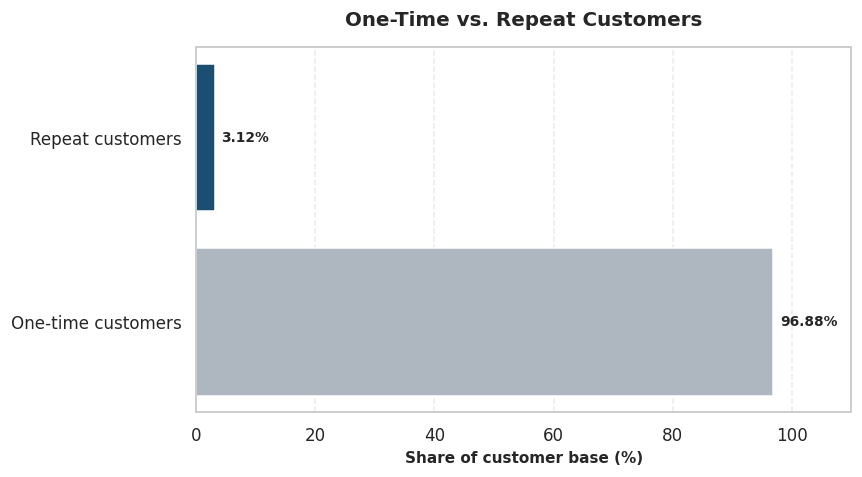

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))

one_time_pct = one_time_customers / total_customers * 100
repeat_pct = repeat_customers / total_customers * 100

bars = ax.barh(
    ["One-time customers", "Repeat customers"],
    [one_time_pct, repeat_pct],
    color=[COLOR_NEUTRAL, COLOR_PRIMARY],
)
style_axes(ax, "One-Time vs. Repeat Customers", xlabel="Share of customer base (%)")
ax.set_xlim(0, 110)
label_hbars(ax, bars)
ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.savefig("charts/kpi_onetime_vs_repeat.png", dpi=150, bbox_inches="tight")
plt.show()

**What this means:** out of every 100 Olist customers in this dataset, only about 3 came back to buy a second time within the observed period. This is the baseline every later finding needs to be read against. Even a factor with a real effect on repeat purchasing is working against a very small starting group.

---
# Part 3: Analysis, Visualization, and Statistical Testing

This is the core of the notebook. Each of the ten questions below follows the same pattern:

1. **Business question**, in plain language
2. **SQL query** that pulls the exact data needed to answer it
3. **Result**, with a chart where a chart adds clarity
4. **Statistical test**, where relevant, to check whether an observed difference is likely to be real or just noise
5. **Takeaway**, in plain language, tying the result back to the business

Two customer-level populations are used throughout, and it matters which one a given number is based on:

- **All observed orders** (including cancelled or unfulfilled ones) are used for anything about *whether* a customer returns, since a customer's status as one-time or repeat should not depend on how their order was fulfilled.
- **Delivered orders only** are used for anything involving money (order value, spending), since those are the only orders that represent a completed, recorded sale.

## Question 1: How large is the repeat-customer opportunity?

**Business question:** What share of customers are one-time buyers versus repeat buyers?

This sets the baseline for everything that follows.

In [8]:
q1_customer_orders = pd.read_sql("""
    SELECT
        c.customer_unique_id,
        COUNT(o.order_id) AS order_count
    FROM customers c
    JOIN orders o
        ON c.customer_id = o.customer_id
    GROUP BY c.customer_unique_id
""", conn)

q1_total = len(q1_customer_orders)
q1_one_time = int((q1_customer_orders["order_count"] == 1).sum())
q1_repeat = int((q1_customer_orders["order_count"] > 1).sum())

print(f"Total customers    : {q1_total:,}")
print(f"One-time customers : {q1_one_time:,} ({q1_one_time/q1_total:.2%})")
print(f"Repeat customers    : {q1_repeat:,} ({q1_repeat/q1_total:.2%})")

Total customers    : 96,096
One-time customers : 93,099 (96.88%)
Repeat customers    : 2,997 (3.12%)


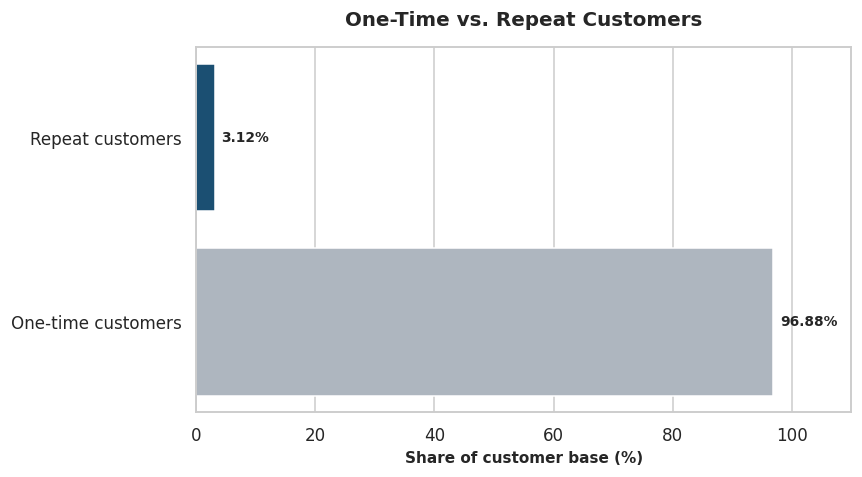

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.5))
rates = [q1_one_time / q1_total * 100, q1_repeat / q1_total * 100]
bars = ax.barh(["One-time customers", "Repeat customers"], rates, color=[COLOR_NEUTRAL, COLOR_PRIMARY])
style_axes(ax, "One-Time vs. Repeat Customers", xlabel="Share of customer base (%)")
ax.set_xlim(0, 110)
label_hbars(ax, bars)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.savefig("charts/h1_onetime_vs_repeat.png", dpi=150, bbox_inches="tight")
plt.show()

**Takeaway:** the customer base is heavily one-time. Fewer than 1 in 30 customers came back to buy again within the observed period. This is a small foundation to build a loyalty program on, and it is the number every later comparison needs to be read against.

## Question 2: How often do repeat customers purchase?

**Business question:** Among the customers who do come back, how many total orders do they typically place?

In [10]:
q2_repeat_orders = pd.read_sql("""
    SELECT
        c.customer_unique_id,
        COUNT(o.order_id) AS order_count
    FROM customers c
    JOIN orders o
        ON c.customer_id = o.customer_id
    GROUP BY c.customer_unique_id
    HAVING COUNT(o.order_id) >= 2
""", conn)

print(f"Repeat customers                 : {len(q2_repeat_orders):,}")
print(f"Average orders per repeat customer: {q2_repeat_orders['order_count'].mean():.2f}")
print(f"Median orders per repeat customer : {q2_repeat_orders['order_count'].median():.0f}")
print(f"Range                             : {q2_repeat_orders['order_count'].min()} to {q2_repeat_orders['order_count'].max()} orders")

order_count_bucket = np.select(
    [
        q2_repeat_orders["order_count"] == 2,
        q2_repeat_orders["order_count"] == 3,
        q2_repeat_orders["order_count"] == 4,
    ],
    ["2 orders", "3 orders", "4 orders"],
    default="5+ orders",
)
q2_repeat_orders = q2_repeat_orders.assign(order_count_bucket=order_count_bucket)

q2_distribution = q2_repeat_orders["order_count_bucket"].value_counts().reindex(
    ["2 orders", "3 orders", "4 orders", "5+ orders"]
)
q2_distribution_pct = (q2_distribution / len(q2_repeat_orders) * 100).round(2)
pd.DataFrame({"repeat_customers": q2_distribution, "share_of_repeat_customers_pct": q2_distribution_pct})

Repeat customers                 : 2,997
Average orders per repeat customer: 2.12
Median orders per repeat customer : 2
Range                             : 2 to 17 orders


,repeat_customers,share_of_repeat_customers_pct
order_count_bucket,,
2 orders,2745,91.59
3 orders,203,6.77
4 orders,30,1.00
5+ orders,19,0.63


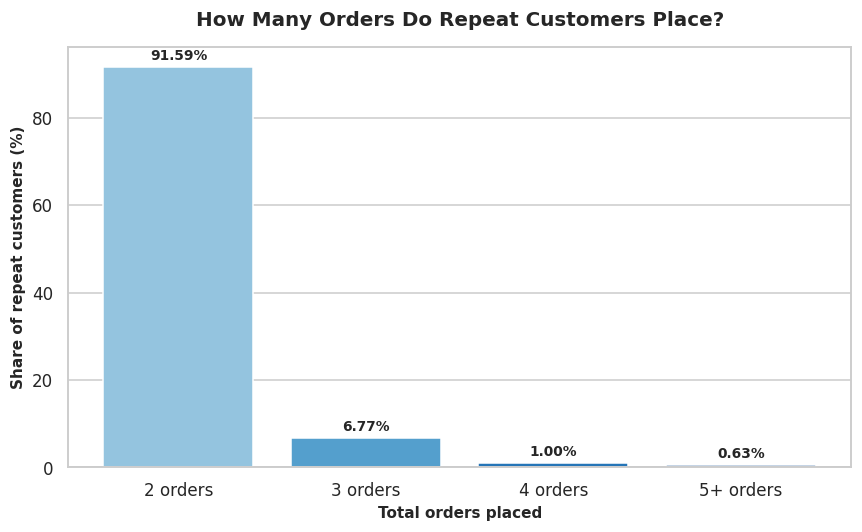

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(q2_distribution_pct.index, q2_distribution_pct.values, color=CMAP_SEQUENTIAL(np.linspace(0.4, 0.9, 4)))
style_axes(ax, "How Many Orders Do Repeat Customers Place?", xlabel="Total orders placed", ylabel="Share of repeat customers (%)")
label_vbars(ax, bars)
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.savefig("charts/h2_order_frequency_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

**Takeaway:** repeat purchasing is shallow, not deep. Over 9 in 10 repeat customers stopped at exactly a second order. Very few went on to place a third, fourth, or fifth. Whatever drives someone to come back once does not, on its own, appear to turn them into a frequent, loyal buyer. That would require a separate effort beyond just converting a first-time buyer into a second-time buyer.

## Question 3: Do one-time and repeat customers spend differently?

**Business question:** Is there a meaningful difference in order value or total spending between one-time and repeat customers?

This uses delivered orders only, since order value only has business meaning for a completed sale.

In [12]:
q3_query = """
    WITH customer_status AS (
        SELECT
            c.customer_unique_id,
            CASE WHEN COUNT(o.order_id) = 1 THEN 'one_time' ELSE 'repeat' END AS customer_type
        FROM customers c
        JOIN orders o
            ON c.customer_id = o.customer_id
        GROUP BY c.customer_unique_id
    ),
    delivered_order_value AS (
        SELECT
            o.order_id,
            c.customer_unique_id,
            SUM(oi.price + oi.freight_value) AS order_value
        FROM customers c
        JOIN orders o
            ON c.customer_id = o.customer_id
        JOIN order_items oi
            ON o.order_id = oi.order_id
        WHERE o.order_status = 'delivered'
        GROUP BY c.customer_unique_id, o.order_id
    )
    SELECT
        dov.customer_unique_id,
        dov.order_id,
        cs.customer_type,
        dov.order_value
    FROM delivered_order_value dov
    JOIN customer_status cs
        ON dov.customer_unique_id = cs.customer_unique_id
"""
q3_order_values = pd.read_sql(q3_query, conn)

avg_order_value_one_time = q3_order_values.loc[q3_order_values.customer_type == "one_time", "order_value"].mean()
avg_order_value_repeat = q3_order_values.loc[q3_order_values.customer_type == "repeat", "order_value"].mean()

q3_customer_spend = q3_order_values.groupby(["customer_unique_id", "customer_type"], as_index=False)["order_value"].sum()
avg_spend_one_time = q3_customer_spend.loc[q3_customer_spend.customer_type == "one_time", "order_value"].mean()
avg_spend_repeat = q3_customer_spend.loc[q3_customer_spend.customer_type == "repeat", "order_value"].mean()

print(f"Average order value,   one-time customers: R$ {avg_order_value_one_time:,.2f}")
print(f"Average order value,   repeat customers  : R$ {avg_order_value_repeat:,.2f}")
print(f"Average total spend,   one-time customers: R$ {avg_spend_one_time:,.2f}")
print(f"Average total spend,   repeat customers  : R$ {avg_spend_repeat:,.2f}")

Average order value,   one-time customers: R$ 160.65
Average order value,   repeat customers  : R$ 147.66
Average total spend,   one-time customers: R$ 160.65
Average total spend,   repeat customers  : R$ 302.30


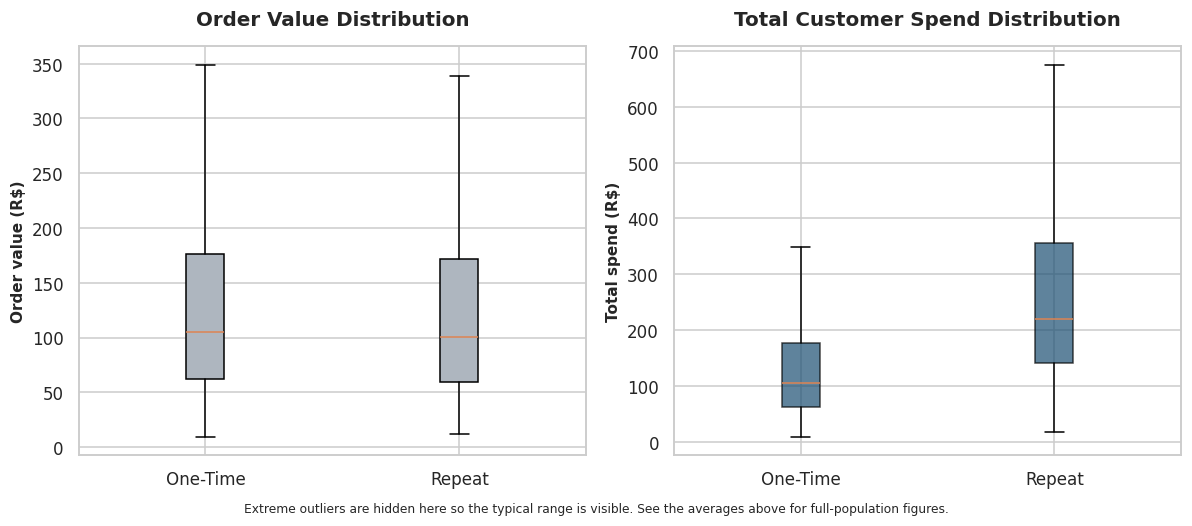

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

order_one = q3_order_values.loc[q3_order_values.customer_type == "one_time", "order_value"]
order_repeat = q3_order_values.loc[q3_order_values.customer_type == "repeat", "order_value"]
axes[0].boxplot([order_one, order_repeat], tick_labels=["One-Time", "Repeat"], showfliers=False,
                patch_artist=True, boxprops=dict(facecolor=COLOR_NEUTRAL))
style_axes(axes[0], "Order Value Distribution", ylabel="Order value (R$)")

spend_one = q3_customer_spend.loc[q3_customer_spend.customer_type == "one_time", "order_value"]
spend_repeat = q3_customer_spend.loc[q3_customer_spend.customer_type == "repeat", "order_value"]
axes[1].boxplot([spend_one, spend_repeat], tick_labels=["One-Time", "Repeat"], showfliers=False,
                patch_artist=True, boxprops=dict(facecolor=COLOR_PRIMARY, alpha=0.7))
style_axes(axes[1], "Total Customer Spend Distribution", ylabel="Total spend (R$)")

fig.suptitle("Extreme outliers are hidden here so the typical range is visible. See the averages above for full-population figures.",
             fontsize=8, y=0.01)
plt.tight_layout()
plt.savefig("charts/h3_value_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

**Statistical test:** a Welch's t-test checks whether the average order value genuinely differs between the two groups, and a Mann-Whitney U test checks the same thing without assuming a normal distribution, which matters here since spending data is always right-skewed.

In [14]:
t_stat, t_p_value = stats.ttest_ind(order_one, order_repeat, equal_var=False)
u_stat, u_p_value = stats.mannwhitneyu(order_one, order_repeat, alternative="two-sided")

print("Welch's t-test on order value (one-time vs. repeat)")
print(f"  t-statistic : {t_stat:.4f}")
print(f"  p-value     : {t_p_value:.2e}")
print(f"  Significant at 0.05: {t_p_value < 0.05}")

print("\nMann-Whitney U test on order value (one-time vs. repeat)")
print(f"  U-statistic : {u_stat:.4f}")
print(f"  p-value     : {u_p_value:.2e}")
print(f"  Significant at 0.05: {u_p_value < 0.05}")

Welch's t-test on order value (one-time vs. repeat)
  t-statistic : 5.3649
  p-value     : 8.35e-08
  Significant at 0.05: True

Mann-Whitney U test on order value (one-time vs. repeat)
  U-statistic : 283594422.0000
  p-value     : 1.49e-04
  Significant at 0.05: True


**Takeaway:** repeat customers place slightly smaller individual orders on average than one-time customers, and both tests confirm this gap is statistically real rather than random noise. But total spending tells the opposite, and more important, story: repeat customers are worth roughly twice as much to the business over time, purely because they buy more than once. The value of a repeat customer comes from repetition, not from placing bigger orders.

## Question 4: Are review scores associated with repeat purchasing?

**Business question:** Do customers who leave different review scores show different repeat-purchase rates?

In [15]:
q4_query = """
    WITH customer_status AS (
        SELECT
            c.customer_unique_id,
            CASE WHEN COUNT(o.order_id) = 1 THEN 'one_time' ELSE 'repeat' END AS customer_type
        FROM customers c
        JOIN orders o
            ON c.customer_id = o.customer_id
        GROUP BY c.customer_unique_id
    ),
    customer_avg_review AS (
        SELECT
            c.customer_unique_id,
            AVG(r.review_score) AS avg_review_score
        FROM customers c
        JOIN orders o
            ON c.customer_id = o.customer_id
        JOIN order_reviews r
            ON o.order_id = r.order_id
        GROUP BY c.customer_unique_id
    )
    SELECT
        cs.customer_unique_id,
        cs.customer_type,
        car.avg_review_score
    FROM customer_status cs
    JOIN customer_avg_review car
        ON cs.customer_unique_id = car.customer_unique_id
"""
q4_reviews = pd.read_sql(q4_query, conn)
q4_reviews["review_group"] = pd.cut(
    q4_reviews["avg_review_score"], bins=[0, 2, 3, 4, 5], labels=["1-2 stars", "3 stars", "4 stars", "5 stars"]
)

q4_summary = q4_reviews.groupby("review_group", observed=False).agg(
    customers=("customer_unique_id", "nunique"),
    repeat_customers=("customer_type", lambda x: (x == "repeat").sum()),
)
q4_summary["repeat_rate_pct"] = (q4_summary["repeat_customers"] / q4_summary["customers"] * 100).round(2)
q4_summary

,customers,repeat_customers,repeat_rate_pct
review_group,,,
1-2 stars,13846,261,1.89
3 stars,8033,403,5.02
4 stars,18517,549,2.96
5 stars,54984,1775,3.23


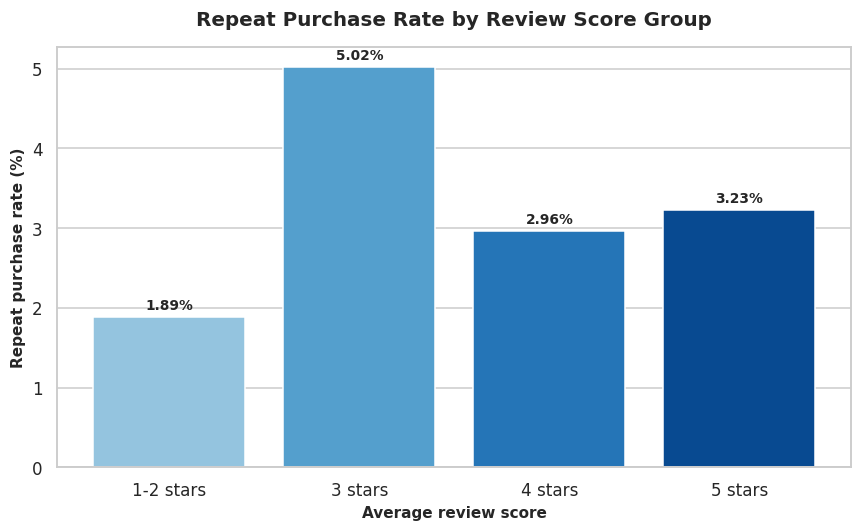

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_data = q4_summary.reset_index()
bars = ax.bar(plot_data["review_group"], plot_data["repeat_rate_pct"],
              color=CMAP_SEQUENTIAL(np.linspace(0.4, 0.9, len(plot_data))))
style_axes(ax, "Repeat Purchase Rate by Review Score Group", xlabel="Average review score", ylabel="Repeat purchase rate (%)")
label_vbars(ax, bars)
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.savefig("charts/h4_repeat_rate_by_review.png", dpi=150, bbox_inches="tight")
plt.show()

**Statistical test:** a Chi-square test of independence checks whether review group and repeat-purchase status are related at all. Cramer's V then measures how strong that relationship actually is, since a large dataset can make even a tiny, unimportant difference "statistically significant.

| Cramer's V | Interpretation |
|---|---|
| below 0.10 | very weak association |
| 0.10 to 0.30 | weak association |
| 0.30 to 0.50 | moderate association |
| above 0.50 | strong association |

In [17]:
def cramers_v(contingency_table):
    chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
    n = contingency_table.to_numpy().sum()
    v = np.sqrt(chi2 / (n * min(contingency_table.shape[0] - 1, contingency_table.shape[1] - 1)))
    return chi2, p_value, dof, v


def effect_size_label(v):
    if v < 0.10:
        return "very weak association"
    elif v < 0.30:
        return "weak association"
    elif v < 0.50:
        return "moderate association"
    return "strong association"


q4_contingency = pd.crosstab(q4_reviews["review_group"], q4_reviews["customer_type"])
chi2, p_value, dof, v = cramers_v(q4_contingency)

print("Chi-square test: review score group vs. repeat-purchase status")
print(f"  chi-square statistic : {chi2:.4f}")
print(f"  p-value               : {p_value:.2e}")
print(f"  degrees of freedom    : {dof}")
print(f"  significant at 0.05   : {p_value < 0.05}")
print(f"  Cramer's V            : {v:.4f} ({effect_size_label(v)})")

Chi-square test: review score group vs. repeat-purchase status
  chi-square statistic : 168.3700
  p-value               : 2.86e-36
  degrees of freedom    : 3
  significant at 0.05   : True
  Cramer's V            : 0.0420 (very weak association)


**Takeaway:** the relationship is statistically significant but practically very weak. Notably, the pattern is not what most people would expect. The 3-star group had the *highest* repeat-purchase rate, not the 5-star group, and 1-2 star customers had the lowest. Review score alone is not a reliable predictor of whether someone comes back. Something else is driving repeat behavior beyond stated satisfaction.

## Question 5: Is delivery performance associated with repeat purchasing?

**Business question:** Do customers whose order arrived late show a different repeat-purchase rate than customers whose order arrived on time?

This looks specifically at each customer's *first* delivered order, since that first experience is what shapes whether they come back.

In [18]:
q5_query = """
    WITH customer_status AS (
        SELECT
            c.customer_unique_id,
            CASE WHEN COUNT(o.order_id) = 1 THEN 'one_time' ELSE 'repeat' END AS customer_type
        FROM customers c
        JOIN orders o
            ON c.customer_id = o.customer_id
        GROUP BY c.customer_unique_id
    ),
    ranked_deliveries AS (
        SELECT
            c.customer_unique_id,
            o.order_estimated_delivery_date,
            o.order_delivered_customer_date,
            ROW_NUMBER() OVER (
                PARTITION BY c.customer_unique_id
                ORDER BY o.order_purchase_timestamp ASC, o.order_id
            ) AS purchase_rank
        FROM customers c
        JOIN orders o
            ON c.customer_id = o.customer_id
        WHERE o.order_status = 'delivered'
            AND o.order_estimated_delivery_date IS NOT NULL
            AND o.order_delivered_customer_date IS NOT NULL
    ),
    first_delivery_status AS (
        SELECT
            customer_unique_id,
            CASE WHEN order_estimated_delivery_date < order_delivered_customer_date
                 THEN 'late_delivery' ELSE 'on_time_delivery' END AS delivery_status
        FROM ranked_deliveries
        WHERE purchase_rank = 1
    )
    SELECT
        cs.customer_unique_id,
        cs.customer_type,
        fds.delivery_status
    FROM customer_status cs
    JOIN first_delivery_status fds
        ON cs.customer_unique_id = fds.customer_unique_id
"""
q5_delivery = pd.read_sql(q5_query, conn)

q5_summary = q5_delivery.groupby("delivery_status").agg(
    customers=("customer_unique_id", "nunique"),
    repeat_customers=("customer_type", lambda x: (x == "repeat").sum()),
)
q5_summary["repeat_rate_pct"] = (q5_summary["repeat_customers"] / q5_summary["customers"] * 100).round(2)
q5_summary

,customers,repeat_customers,repeat_rate_pct
delivery_status,,,
late_delivery,7605,208,2.74
on_time_delivery,85745,2771,3.23


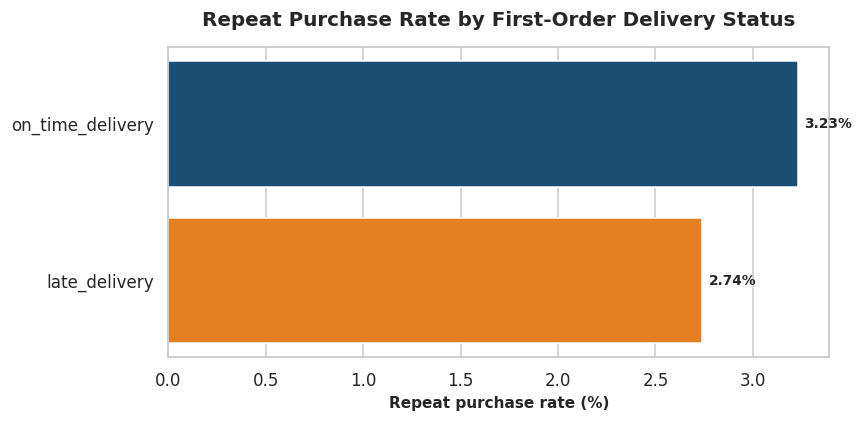

In [19]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_data = q5_summary.reset_index().sort_values("repeat_rate_pct")
bars = ax.barh(plot_data["delivery_status"], plot_data["repeat_rate_pct"], color=[COLOR_ACCENT, COLOR_PRIMARY])
style_axes(ax, "Repeat Purchase Rate by First-Order Delivery Status", xlabel="Repeat purchase rate (%)")
label_hbars(ax, bars)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.savefig("charts/h5_repeat_rate_by_delivery.png", dpi=150, bbox_inches="tight")
plt.show()

In [20]:
q5_contingency = pd.crosstab(q5_delivery["delivery_status"], q5_delivery["customer_type"])
chi2, p_value, dof, v = cramers_v(q5_contingency)

print("Chi-square test: first-order delivery status vs. repeat-purchase status")
print(f"  chi-square statistic : {chi2:.4f}")
print(f"  p-value               : {p_value:.2e}")
print(f"  significant at 0.05   : {p_value < 0.05}")
print(f"  Cramer's V            : {v:.4f} ({effect_size_label(v)})")

Chi-square test: first-order delivery status vs. repeat-purchase status
  chi-square statistic : 5.4173
  p-value               : 1.99e-02
  significant at 0.05   : True
  Cramer's V            : 0.0076 (very weak association)


**Takeaway:** customers whose first order arrived on time were slightly more likely to return, and the difference is statistically real. But it is a very small gap in practical terms, less than one percentage point. On-time delivery matters and is worth protecting, but it is not, by itself, a lever strong enough to meaningfully move the repeat-purchase rate.

## Question 6: Does customer geography relate to retention?

**Business question:** Does the repeat-purchase rate vary by the customer's home state?

This uses the state associated with each customer's first order.

In [21]:
q6_query = """
    WITH customer_status AS (
        SELECT
            c.customer_unique_id,
            CASE WHEN COUNT(o.order_id) = 1 THEN 'one_time' ELSE 'repeat' END AS customer_type
        FROM customers c
        JOIN orders o
            ON c.customer_id = o.customer_id
        GROUP BY c.customer_unique_id
    ),
    ranked_orders AS (
        SELECT
            c.customer_unique_id,
            c.customer_state,
            ROW_NUMBER() OVER (
                PARTITION BY c.customer_unique_id
                ORDER BY o.order_purchase_timestamp ASC, o.order_id
            ) AS purchase_rank
        FROM customers c
        JOIN orders o
            ON c.customer_id = o.customer_id
    )
    SELECT
        cs.customer_unique_id,
        ro.customer_state,
        cs.customer_type
    FROM customer_status cs
    JOIN ranked_orders ro
        ON cs.customer_unique_id = ro.customer_unique_id
    WHERE ro.purchase_rank = 1
"""
q6_geography = pd.read_sql(q6_query, conn)

q6_summary = q6_geography.groupby("customer_state").agg(
    customers=("customer_unique_id", "nunique"),
    repeat_customers=("customer_type", lambda x: (x == "repeat").sum()),
)
q6_summary["repeat_rate_pct"] = (q6_summary["repeat_customers"] / q6_summary["customers"] * 100).round(2)
q6_summary = q6_summary.sort_values("repeat_rate_pct", ascending=False)

print(f"Repeat rate ranges from {q6_summary['repeat_rate_pct'].min():.2f}% to {q6_summary['repeat_rate_pct'].max():.2f}% across states.")
q6_summary

Repeat rate ranges from 1.49% to 5.19% across states.


,customers,repeat_customers,repeat_rate_pct
customer_state,,,
AC,77,4,5.19
RO,239,10,4.18
MT,875,30,3.43
RJ,12379,424,3.43
GO,1951,65,3.33
AL,401,13,3.24
SP,40291,1302,3.23
RS,5276,168,3.18
DF,2074,64,3.09


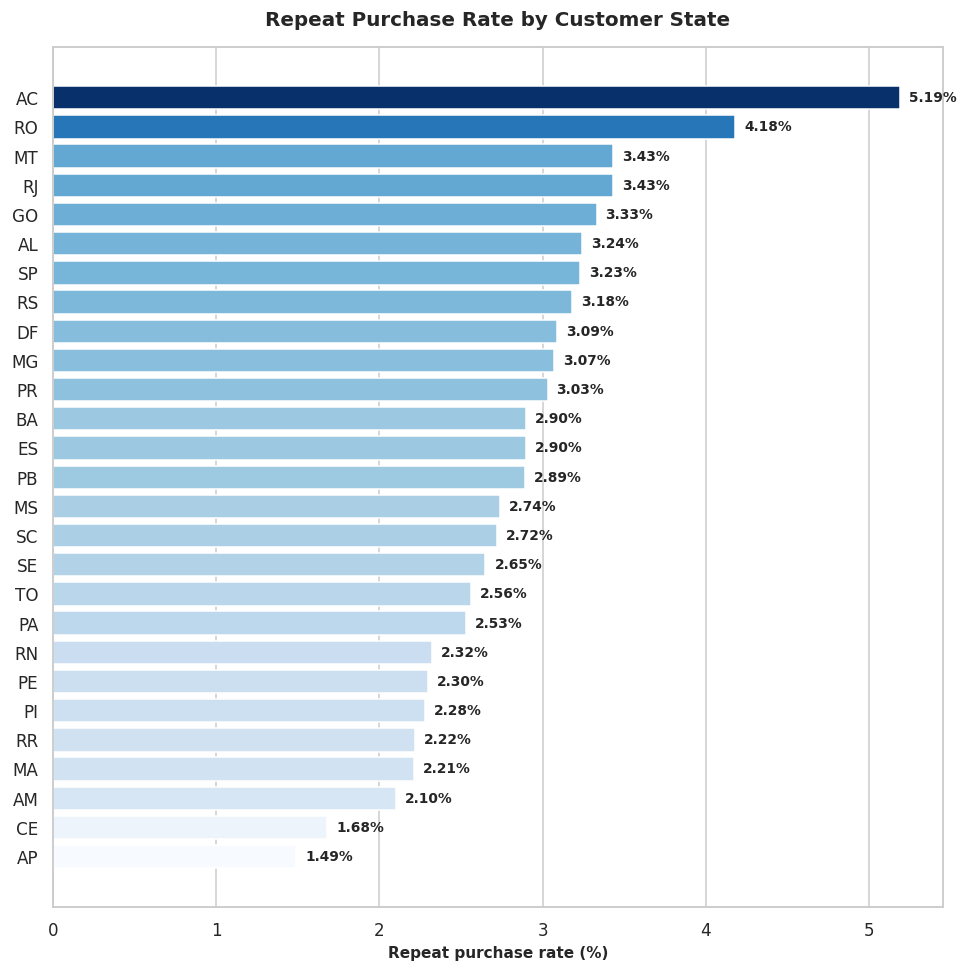

In [22]:
fig, ax = plt.subplots(figsize=(9, 9))
plot_data = q6_summary.reset_index().sort_values("repeat_rate_pct")
colors = CMAP_SEQUENTIAL(mcolors.Normalize(vmin=plot_data["repeat_rate_pct"].min(), vmax=plot_data["repeat_rate_pct"].max())(plot_data["repeat_rate_pct"]))
bars = ax.barh(plot_data["customer_state"], plot_data["repeat_rate_pct"], color=colors)
style_axes(ax, "Repeat Purchase Rate by Customer State", xlabel="Repeat purchase rate (%)")
label_hbars(ax, bars)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.savefig("charts/h6_repeat_rate_by_state.png", dpi=150, bbox_inches="tight")
plt.show()

In [23]:
q6_contingency = pd.crosstab(q6_geography["customer_state"], q6_geography["customer_type"])
chi2, p_value, dof, v = cramers_v(q6_contingency)

print("Chi-square test: customer state vs. repeat-purchase status")
print(f"  chi-square statistic : {chi2:.4f}")
print(f"  p-value               : {p_value:.4f}")
print(f"  significant at 0.05   : {p_value < 0.05}")
print(f"  Cramer's V            : {v:.4f} ({effect_size_label(v)})")

Chi-square test: customer state vs. repeat-purchase status
  chi-square statistic : 30.9902
  p-value               : 0.2286
  significant at 0.05   : False
  Cramer's V            : 0.0180 (very weak association)


**Takeaway:** unlike every other factor tested so far, geography does not even clear the bar of statistical significance. The differences between states look meaningful in the chart, but with this many states and relatively few repeat customers in some of them, those differences are consistent with random variation. Location is not a useful lens for a retention strategy here.

## Question 7: Is a customer's first product category associated with repeat purchasing?

**Business question:** Do customers whose first purchase falls into different product categories show different repeat-purchase rates?

Each customer is assigned the category of the highest-priced item in their first order, so that a customer is counted only once even if their first order contained several products.

In [24]:
q7_query = """
    WITH customer_status AS (
        SELECT
            c.customer_unique_id,
            CASE WHEN COUNT(o.order_id) = 1 THEN 'one_time' ELSE 'repeat' END AS customer_type
        FROM customers c
        JOIN orders o
            ON c.customer_id = o.customer_id
        GROUP BY c.customer_unique_id
    ),
    first_order AS (
        SELECT
            c.customer_unique_id,
            o.order_id,
            ROW_NUMBER() OVER (
                PARTITION BY c.customer_unique_id
                ORDER BY o.order_purchase_timestamp ASC, o.order_id
            ) AS purchase_rank
        FROM customers c
        JOIN orders o
            ON c.customer_id = o.customer_id
    ),
    first_order_items AS (
        SELECT
            fo.customer_unique_id,
            oi.price,
            oi.product_id,
            p.product_category_name
        FROM first_order fo
        JOIN order_items oi
            ON fo.order_id = oi.order_id
        JOIN products p
            ON oi.product_id = p.product_id
        WHERE fo.purchase_rank = 1
            AND p.product_category_name IS NOT NULL
    ),
    top_category_per_customer AS (
        SELECT
            customer_unique_id,
            product_category_name,
            ROW_NUMBER() OVER (
                PARTITION BY customer_unique_id
                ORDER BY price DESC, product_category_name, product_id
            ) AS category_rank
        FROM first_order_items
    )
    SELECT
        cs.customer_unique_id,
        cs.customer_type,
        tcpc.product_category_name
    FROM customer_status cs
    JOIN top_category_per_customer tcpc
        ON cs.customer_unique_id = tcpc.customer_unique_id
    WHERE tcpc.category_rank = 1
"""
q7_categories = pd.read_sql(q7_query, conn)

q7_summary = q7_categories.groupby("product_category_name").agg(
    customers=("customer_unique_id", "nunique"),
    repeat_customers=("customer_type", lambda x: (x == "repeat").sum()),
)
q7_summary["repeat_rate_pct"] = (q7_summary["repeat_customers"] / q7_summary["customers"] * 100).round(2)

# Keep only categories with a reasonably sized customer base, then take the top 10 by repeat rate
q7_top10 = (
    q7_summary[q7_summary["customers"] > 500]
    .sort_values("repeat_rate_pct", ascending=False)
    .head(10)
)

# Translate category names to English for readability
translation_map = dict(zip(category_translation["product_category_name"], category_translation["product_category_name_english"]))
q7_top10 = q7_top10.reset_index()
q7_top10["category_english"] = q7_top10["product_category_name"].map(translation_map).fillna(q7_top10["product_category_name"])
q7_top10 = q7_top10.sort_values("repeat_rate_pct")
q7_top10[["category_english", "customers", "repeat_customers", "repeat_rate_pct"]]

,category_english,customers,repeat_customers,repeat_rate_pct
9,perfumery,3060,86,2.81
8,health_beauty,8531,247,2.90
7,garden_tools,3381,100,2.96
6,pet_shop,1652,49,2.97
5,computers_accessories,6446,192,2.98
4,sports_leisure,7368,290,3.94
3,bed_bath_table,8893,402,4.52
2,furniture_decor,6024,280,4.65
1,fashion_bags_accessories,1735,103,5.94
0,home_appliances,689,63,9.14


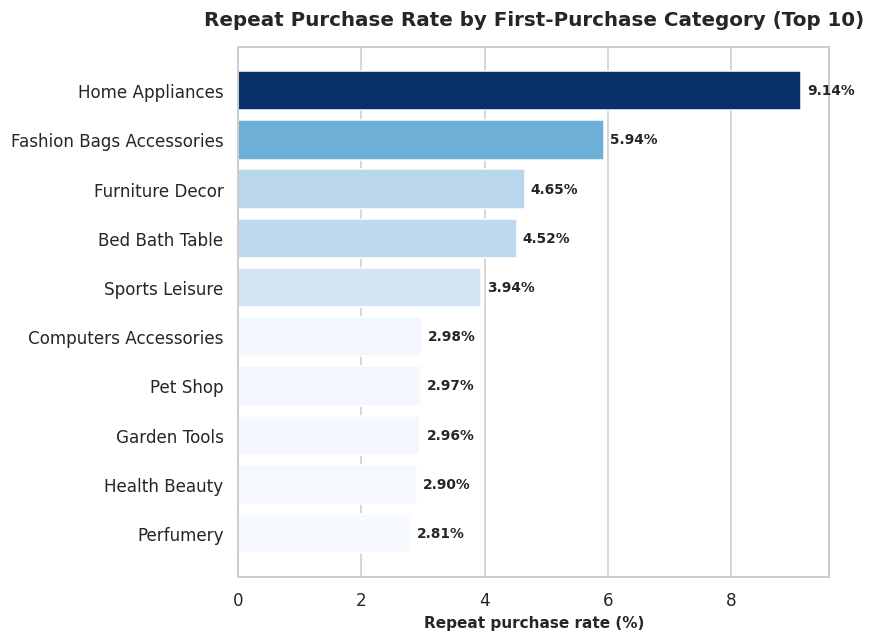

In [25]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = CMAP_SEQUENTIAL(mcolors.Normalize(vmin=q7_top10["repeat_rate_pct"].min(), vmax=q7_top10["repeat_rate_pct"].max())(q7_top10["repeat_rate_pct"]))
bars = ax.barh(q7_top10["category_english"].str.replace("_", " ").str.title(), q7_top10["repeat_rate_pct"], color=colors)
style_axes(ax, "Repeat Purchase Rate by First-Purchase Category (Top 10)", xlabel="Repeat purchase rate (%)")
label_hbars(ax, bars)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.savefig("charts/h7_repeat_rate_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

In [26]:
q7_contingency = pd.crosstab(q7_categories["product_category_name"], q7_categories["customer_type"])
chi2, p_value, dof, v = cramers_v(q7_contingency)

print("Chi-square test: first-purchase category vs. repeat-purchase status")
print(f"  chi-square statistic : {chi2:.4f}")
print(f"  p-value               : {p_value:.2e}")
print(f"  significant at 0.05   : {p_value < 0.05}")
print(f"  Cramer's V            : {v:.4f} ({effect_size_label(v)})")

Chi-square test: first-purchase category vs. repeat-purchase status
  chi-square statistic : 446.4562
  p-value               : 2.08e-55
  significant at 0.05   : True
  Cramer's V            : 0.0689 (very weak association)


**Takeaway:** categories like home appliances and fashion bags and accessories show a noticeably higher repeat rate than the rest, and the relationship is statistically significant. But the effect size is still weak. A customer's first product category offers a small directional signal at best, useful perhaps for prioritizing which categories to run a retention campaign in first, but not a reliable standalone predictor.

## Question 8: How long does it take customers to make a second purchase?

**Business question:** Among customers who do return, how much time passes between their first and second purchase?

This is one of the most actionable numbers in the whole analysis, since it defines the window during which a follow-up campaign is most likely to matter.

In [27]:
q8_query = """
    WITH customer_status AS (
        SELECT
            c.customer_unique_id,
            CASE WHEN COUNT(o.order_id) = 1 THEN 'one_time' ELSE 'repeat' END AS customer_type
        FROM customers c
        JOIN orders o
            ON c.customer_id = o.customer_id
        GROUP BY c.customer_unique_id
    ),
    ordered_purchases AS (
        SELECT
            c.customer_unique_id,
            o.order_purchase_timestamp,
            ROW_NUMBER() OVER (
                PARTITION BY c.customer_unique_id
                ORDER BY o.order_purchase_timestamp ASC, o.order_id
            ) AS purchase_seq
        FROM customers c
        JOIN orders o
            ON c.customer_id = o.customer_id
    ),
    first_and_second AS (
        SELECT
            customer_unique_id,
            MIN(CASE WHEN purchase_seq = 1 THEN order_purchase_timestamp END) AS first_purchase,
            MIN(CASE WHEN purchase_seq = 2 THEN order_purchase_timestamp END) AS second_purchase
        FROM ordered_purchases
        WHERE purchase_seq IN (1, 2)
        GROUP BY customer_unique_id
    )
    SELECT
        cs.customer_unique_id,
        cs.customer_type,
        JULIANDAY(DATE(fas.second_purchase)) - JULIANDAY(DATE(fas.first_purchase)) AS days_to_second_purchase
    FROM customer_status cs
    JOIN first_and_second fas
        ON cs.customer_unique_id = fas.customer_unique_id
    WHERE fas.second_purchase IS NOT NULL
"""
q8_time_to_second = pd.read_sql(q8_query, conn)
q8_time_to_second["days_to_second_purchase"].describe()

count    2997.000000
mean       80.348348
std       110.191314
min         0.000000
25%         0.000000
50%        28.000000
75%       123.000000
max       609.000000
Name: days_to_second_purchase, dtype: float64

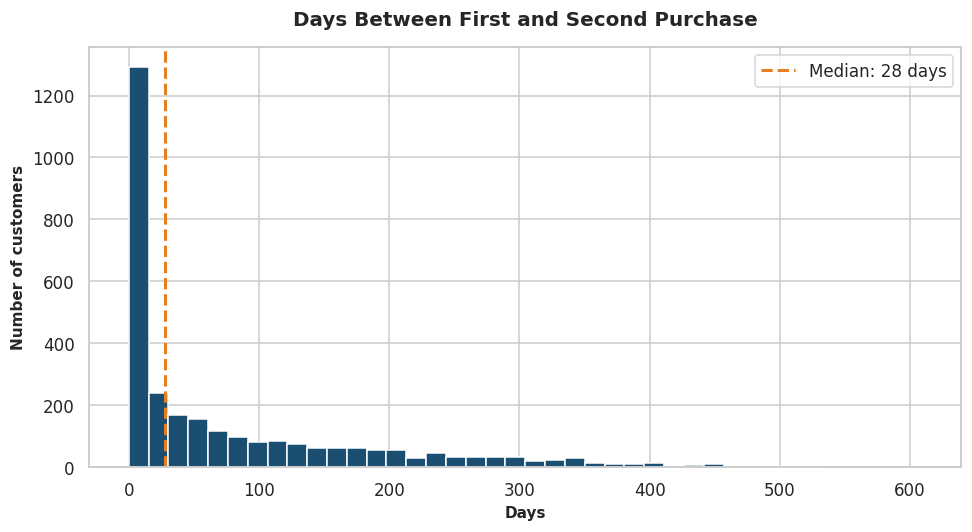

In [28]:
fig, ax = plt.subplots(figsize=(9, 5))
median_days = q8_time_to_second["days_to_second_purchase"].median()
ax.hist(q8_time_to_second["days_to_second_purchase"], bins=40, color=COLOR_PRIMARY, edgecolor="white")
ax.axvline(median_days, color=COLOR_ACCENT, linestyle="--", linewidth=2, label=f"Median: {median_days:.0f} days")
style_axes(ax, "Days Between First and Second Purchase", xlabel="Days", ylabel="Number of customers")
ax.legend()
plt.tight_layout()
plt.savefig("charts/h8_days_to_second_purchase.png", dpi=150, bbox_inches="tight")
plt.show()

**Takeaway:** the median time to a second purchase is 28 days, but the average is much higher at around 80 days. That gap tells its own story: the distribution is heavily right-skewed. Most repeat customers return quickly, within about a month, while a smaller group returns much later and pulls the average up. For a retention campaign, this points to the first 3 to 4 weeks after a purchase as the highest-value window for a follow-up touchpoint.

## Question 9: Does a combination of poor experience factors relate to lower retention?

**Business question:** Individually, review score and delivery speed showed only weak relationships with repeat purchasing. Does combining a low review score with a late delivery show a stronger pattern than either factor alone?

**A data quality note before running this query:** 547 orders in this dataset have more than one review attached to them. Ranking each customer's first order with a window function that joins to reviews can silently pick a different one of those duplicate reviews each time the query runs, unless the ranking is given a fully deterministic tiebreaker. The query below sorts by `review_id` as a final tiebreaker to guarantee the same, reproducible result every time.

In [29]:
q9_query = """
    WITH customer_status AS (
        SELECT
            c.customer_unique_id,
            CASE WHEN COUNT(o.order_id) = 1 THEN 'one_time' ELSE 'repeat' END AS customer_type
        FROM customers c
        JOIN orders o
            ON c.customer_id = o.customer_id
        GROUP BY c.customer_unique_id
    ),
    ranked_first_order AS (
        SELECT
            c.customer_unique_id,
            r.review_score,
            o.order_estimated_delivery_date,
            o.order_delivered_customer_date,
            ROW_NUMBER() OVER (
                PARTITION BY c.customer_unique_id
                ORDER BY o.order_purchase_timestamp ASC, o.order_id, r.review_id
            ) AS purchase_rank
        FROM customers c
        JOIN orders o
            ON c.customer_id = o.customer_id
        JOIN order_reviews r
            ON o.order_id = r.order_id
        WHERE o.order_status = 'delivered'
            AND o.order_estimated_delivery_date IS NOT NULL
            AND o.order_delivered_customer_date IS NOT NULL
    ),
    first_order_tags AS (
        SELECT
            customer_unique_id,
            CASE WHEN order_estimated_delivery_date < order_delivered_customer_date
                 THEN 'late' ELSE 'on_time' END AS delivery_status,
            CASE WHEN review_score < 3 THEN 'low_score' ELSE 'high_score' END AS review_status
        FROM ranked_first_order
        WHERE purchase_rank = 1
    ),
    combined_experience AS (
        SELECT
            customer_unique_id,
            CASE
                WHEN delivery_status = 'late' AND review_status = 'low_score' THEN 'poor_experience'
                WHEN delivery_status = 'on_time' AND review_status = 'high_score' THEN 'better_experience'
                ELSE 'mixed_experience'
            END AS customer_experience
        FROM first_order_tags
    )
    SELECT
        cs.customer_unique_id,
        cs.customer_type,
        ce.customer_experience
    FROM customer_status cs
    JOIN combined_experience ce
        ON cs.customer_unique_id = ce.customer_unique_id
"""
q9_experience = pd.read_sql(q9_query, conn)

q9_summary = q9_experience.groupby("customer_experience").agg(
    customers=("customer_unique_id", "nunique"),
    repeat_customers=("customer_type", lambda x: (x == "repeat").sum()),
)
q9_summary["repeat_rate_pct"] = (q9_summary["repeat_customers"] / q9_summary["customers"] * 100).round(2)
q9_summary = q9_summary.reindex(["poor_experience", "mixed_experience", "better_experience"])
q9_summary

,customers,repeat_customers,repeat_rate_pct
customer_experience,,,
poor_experience,4041,108,2.67
mixed_experience,11285,385,3.41
better_experience,77421,2477,3.20


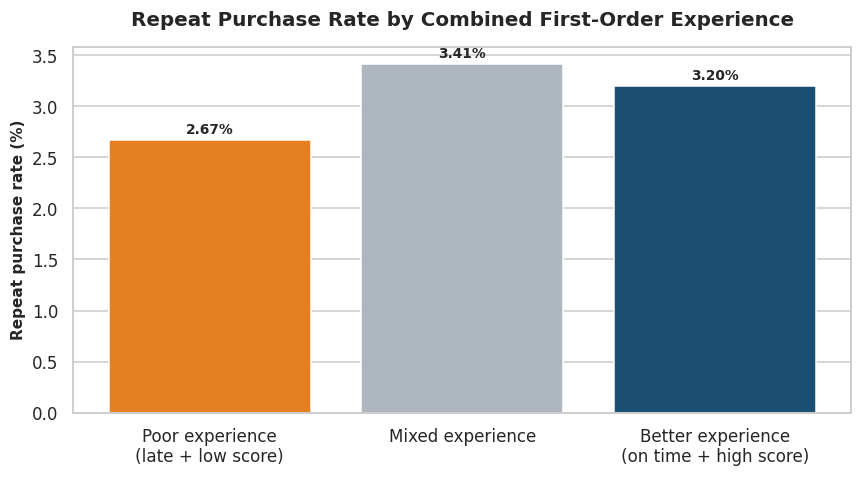

In [30]:
fig, ax = plt.subplots(figsize=(8, 4.5))
plot_data = q9_summary.reset_index()
label_map = {"poor_experience": "Poor experience\n(late + low score)", "mixed_experience": "Mixed experience", "better_experience": "Better experience\n(on time + high score)"}
plot_data["label"] = plot_data["customer_experience"].map(label_map)
bars = ax.bar(plot_data["label"], plot_data["repeat_rate_pct"], color=[COLOR_ACCENT, COLOR_NEUTRAL, COLOR_PRIMARY])
style_axes(ax, "Repeat Purchase Rate by Combined First-Order Experience", ylabel="Repeat purchase rate (%)")
label_vbars(ax, bars)
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.savefig("charts/h9_repeat_rate_by_experience.png", dpi=150, bbox_inches="tight")
plt.show()

In [31]:
q9_contingency = pd.crosstab(q9_experience["customer_experience"], q9_experience["customer_type"])
chi2, p_value, dof, v = cramers_v(q9_contingency)

print("Chi-square test: combined experience vs. repeat-purchase status")
print(f"  chi-square statistic : {chi2:.4f}")
print(f"  p-value               : {p_value:.2e}")
print(f"  significant at 0.05   : {p_value < 0.05}")
print(f"  Cramer's V            : {v:.4f} ({effect_size_label(v)})")

Chi-square test: combined experience vs. repeat-purchase status
  chi-square statistic : 5.2549
  p-value               : 7.23e-02
  significant at 0.05   : False
  Cramer's V            : 0.0075 (very weak association)


**Takeaway:** the direction is what you would expect. Customers with a genuinely poor first experience had the lowest observed repeat rate of the three groups, and better experience had the highest. But once the review-tie issue above is handled correctly, this difference no longer clears the bar of statistical significance (p = 0.072). With this sample size, the gap between groups is consistent with random variation. Combining review score and delivery status does not produce a stronger, more reliable signal than looking at either factor alone.

## Question 10: Which characteristics, combined, best explain repeat purchasing?

**Business question:** Every factor tested individually showed only a weak relationship with repeat purchasing. Does combining review score, delivery status, state, and product category into a single model do meaningfully better at telling repeat customers apart from one-time customers?

This is the one place in the analysis where Python does more than statistics and charting. A logistic regression model is trained to predict whether a customer is a repeat buyer, using their first-order characteristics as inputs. The SQL below assembles the modeling dataset.

In [32]:
first_review_query = """
    WITH ranked_reviews AS (
        SELECT
            c.customer_unique_id,
            r.review_score AS first_review_score,
            ROW_NUMBER() OVER (
                PARTITION BY c.customer_unique_id
                ORDER BY o.order_purchase_timestamp ASC, o.order_id, r.review_id
            ) AS purchase_rank
        FROM customers c
        JOIN orders o
            ON c.customer_id = o.customer_id
        JOIN order_reviews r
            ON o.order_id = r.order_id
        WHERE o.order_status = 'delivered'
    )
    SELECT customer_unique_id, first_review_score
    FROM ranked_reviews
    WHERE purchase_rank = 1
"""
first_review_df = pd.read_sql(first_review_query, conn)

customer_type_query = """
    SELECT
        c.customer_unique_id,
        CASE WHEN COUNT(o.order_id) = 1 THEN 'one_time' ELSE 'repeat' END AS customer_type
    FROM customers c
    JOIN orders o
        ON c.customer_id = o.customer_id
    GROUP BY c.customer_unique_id
"""
customer_type_df = pd.read_sql(customer_type_query, conn)

# Reuse the delivery status, state, and category tables built in Q5, Q6, Q7
model_df = customer_type_df.copy()
model_df = model_df.merge(first_review_df, on="customer_unique_id", how="left")
model_df = model_df.merge(q5_delivery.drop(columns=["customer_type"]), on="customer_unique_id", how="left")
model_df = model_df.merge(q6_geography.drop(columns=["customer_type"]), on="customer_unique_id", how="left")
model_df = model_df.merge(q7_categories.drop(columns=["customer_type"]), on="customer_unique_id", how="left")
model_df["is_repeat"] = (model_df["customer_type"] == "repeat").astype(int)

print(f"Customers available for modeling: {len(model_df):,}")
model_df.head()

Customers available for modeling: 96,096


,customer_unique_id,customer_type,first_review_score,delivery_status,customer_state,product_category_name,is_repeat
0,0000366f3b9a7992bf8c76cfdf3221e2,one_time,5.0,on_time_delivery,SP,cama_mesa_banho,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,one_time,4.0,on_time_delivery,SP,beleza_saude,0
2,0000f46a3911fa3c0805444483337064,one_time,3.0,on_time_delivery,SC,papelaria,0
3,0000f6ccb0745a6a4b88665a16c9f078,one_time,4.0,on_time_delivery,PA,telefonia,0
4,0004aac84e0df4da2b147fca70cf8255,one_time,5.0,on_time_delivery,SP,telefonia,0


In [33]:
features = ["first_review_score", "delivery_status", "customer_state", "product_category_name"]
model_data = model_df[features + ["is_repeat"]].dropna()

X = pd.get_dummies(model_data[features], drop_first=True)
y = model_data["is_repeat"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# class_weight="balanced" compensates for how rare repeat customers are in the data
log_model = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)
y_proba = log_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
cm = confusion_matrix(y_test, y_pred)

print(f"Rows used to train and test the model: {len(model_data):,}")
print(f"Accuracy : {accuracy:.2%}")
print(f"ROC-AUC  : {auc:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["No repeat", "Repeat"]))

Rows used to train and test the model: 91,431
Accuracy : 64.94%
ROC-AUC  : 0.5727

              precision    recall  f1-score   support

   No repeat       0.97      0.66      0.78     17692
      Repeat       0.04      0.46      0.08       595

    accuracy                           0.65     18287
   macro avg       0.51      0.56      0.43     18287
weighted avg       0.94      0.65      0.76     18287



**Reading the results:** accuracy alone is misleading here because repeat customers are so rare. A model that always guessed "no repeat" would already be right about 97% of the time and would still be useless. ROC-AUC and the confusion matrix below give a truer picture of whether the model can actually separate the two groups.

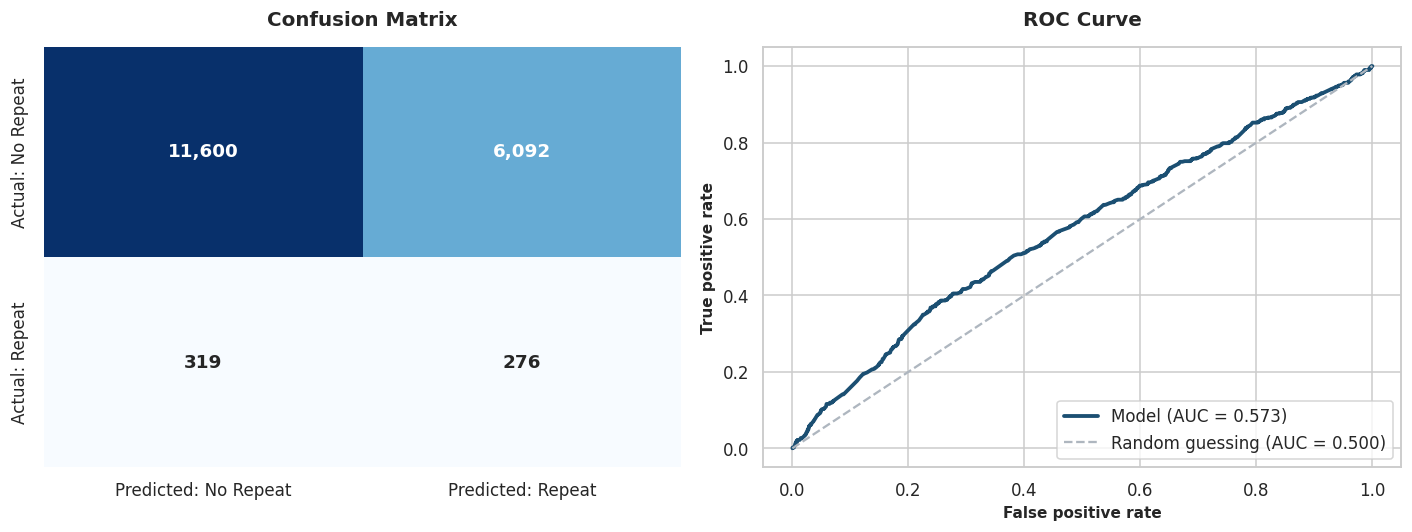

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(
    cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=axes[0],
    xticklabels=["Predicted: No Repeat", "Predicted: Repeat"],
    yticklabels=["Actual: No Repeat", "Actual: Repeat"],
    annot_kws={"fontsize": 12, "fontweight": "bold"},
)
style_axes(axes[0], "Confusion Matrix")

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color=COLOR_PRIMARY, linewidth=2.5, label=f"Model (AUC = {auc:.3f})")
axes[1].plot([0, 1], [0, 1], color=COLOR_NEUTRAL, linestyle="--", linewidth=1.5, label="Random guessing (AUC = 0.500)")
style_axes(axes[1], "ROC Curve", xlabel="False positive rate", ylabel="True positive rate")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.savefig("charts/h10_model_performance.png", dpi=150, bbox_inches="tight")
plt.show()

In [35]:
odds_ratios = np.exp(log_model.coef_[0])
odds_table = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": log_model.coef_[0],
    "odds_ratio": odds_ratios,
})
odds_table["effect"] = np.where(
    odds_table["odds_ratio"] > 1,
    "increases odds of repeat purchase",
    "decreases odds of repeat purchase",
)
odds_table = odds_table.reindex(odds_table["odds_ratio"].sub(1).abs().sort_values(ascending=False).index)
odds_table.head(10)

,feature,coefficient,odds_ratio,effect
31,product_category_name_artes_e_artesanato,1.818857,6.164809,increases odds of repeat purchase
64,product_category_name_fashion_roupa_infanto_ju...,1.731955,5.651690,increases odds of repeat purchase
79,product_category_name_moveis_colchao_e_estofado,1.683389,5.383772,increases odds of repeat purchase
55,product_category_name_eletrodomesticos,1.611732,5.011486,increases odds of repeat purchase
63,product_category_name_fashion_roupa_feminina,1.606178,4.983725,increases odds of repeat purchase
73,product_category_name_la_cuisine,1.520137,4.572853,increases odds of repeat purchase
65,product_category_name_fashion_roupa_masculina,1.348805,3.852817,increases odds of repeat purchase
61,product_category_name_fashion_calcados,1.276360,3.583572,increases odds of repeat purchase
60,product_category_name_fashion_bolsas_e_acessorios,1.078596,2.940547,increases odds of repeat purchase
83,product_category_name_moveis_quarto,0.982911,2.672224,increases odds of repeat purchase


**Takeaway:** the ROC curve sits only modestly above the diagonal random-guessing line, and an AUC of 0.57 confirms it. For comparison, a genuinely useful predictive model typically reaches an AUC of 0.75 or higher. The confusion matrix tells the same story in a different way: the model correctly flags less than half of actual repeat customers, and the large majority of customers it flags as "likely to repeat" turn out not to. Some individual factors, on-time delivery in particular, do nudge the odds in the expected direction, but not by enough to make the model reliable for targeting.

This is itself a useful finding. It means repeat purchasing at Olist is not well explained by the customer and order attributes available in this dataset. Whatever actually drives someone to buy a second time is likely something this data does not capture, such as changing needs, competitor pricing, or promotional timing.

**Limitation:** this model measures association, not causation, and the repeat-customer group is a small fraction of the total, which limits how much a model can learn about it no matter which algorithm is used. These results should be read as evidence that the available variables are insufficient for reliable prediction, not as a finished targeting tool.

---
# Part 4: Findings, Recommendations, and Limitations

## Key Findings

- **96.88%** of customers were one-time buyers. Only **3.12%** made a repeat purchase within the observed period.
- Among customers who did return, **9 in 10** stopped after exactly a second order. Deep repeat buying is rare even among repeat customers.
- The median time to a second purchase was **28 days**. The average was much higher (about 80 days) because a smaller group of customers returned much later, pulling the average up.
- Repeat customers placed slightly smaller individual orders on average (**R$148** vs. **R$161**) but spent roughly twice as much overall (**R$302** vs. **R$161**), since their value comes from repetition rather than order size.
- Review score, delivery performance, and product category all showed a statistically significant relationship with repeat purchasing, but every one of these relationships was weak in practical terms (Cramer's V well under 0.10 in most cases). Customer geography and the combined review-and-delivery experience did not clear the bar of statistical significance at all.
- A logistic regression model combining all of these factors reached an ROC-AUC of only **0.57**, barely better than a coin flip, confirming that this dataset does not contain a strong predictor of who becomes a repeat customer.

## Business Recommendations

- **Focus on converting first-time buyers into second-time buyers.** This is where the largest opportunity sits, since the drop-off between a first and second purchase is the single biggest gap in the funnel.
- **Time follow-up offers around the first month after purchase.** The 28-day median time to a second purchase suggests this is the highest-value window for a reminder, discount, or engagement email.
- **Keep improving delivery reliability**, since it is the one experience factor with a directionally consistent, if small, relationship to retention.
- **Do not rely on review score, delivery status, geography, or category alone (or combined) to target retention campaigns.** None of them, individually or together, reliably separates repeat customers from one-time customers in this data.
- **Do not put the current predictive model into production for customer targeting.** An AUC of 0.57 is not accurate enough to act on. Improving it would require richer behavioral data, such as browsing activity, marketing touchpoints, or pricing history, none of which is present in this dataset.

## Limitations

- This analysis identifies **associations**, not **causes**. A statistically significant relationship between two variables does not mean one causes the other.
- Repeat customers make up only about 3% of the customer base. This imbalance limits how much any statistical test or model can learn about what makes them different, simply because there are relatively few of them to learn from.
- Customer status (one-time vs. repeat) is based only on orders observed within the dataset's 2016 to 2018 window. Some customers labeled "one-time" here may have purchased again after the data was collected.
- The dataset does not include marketing, pricing, or competitor information, all of which plausibly influence repeat purchasing but cannot be tested here.

## Summary Table

| Area | Result |
|---|---|
| Customer base | 96,096 unique customers |
| One-time customers | 93,099 (96.88%) |
| Repeat customers | 2,997 (3.12%) |
| Average orders per customer | 1.03 |
| Median orders among repeat customers | 2 |
| Median time to second purchase | 28 days |
| Average order value, one-time customers | R$ 160.65 |
| Average order value, repeat customers | R$ 147.66 |
| Average total spend, one-time customers | R$ 160.65 |
| Average total spend, repeat customers | R$ 302.30 |
| Review score finding | Statistically significant, very weak association (Cramer's V = 0.042) |
| Delivery performance finding | Statistically significant, very weak association (Cramer's V = 0.008) |
| Geography finding | Not statistically significant (p = 0.229) |
| Product category finding | Statistically significant, weak association (Cramer's V = 0.069) |
| Combined experience finding | Not statistically significant (p = 0.072) |
| Predictive model | Logistic regression |
| Model accuracy | 65% |
| Model ROC-AUC | 0.57 |
| Model recall for repeat customers | 46% |
| Model precision for repeat customers | 4% |
| Overall conclusion | Repeat purchasing is rare and not well explained by the customer, experience, or product variables available in this dataset. Timing (the first month after purchase) is the clearest actionable lever. |